# Model Notebook


## import the necassary libraries

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dense,MaxPooling2D,Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Activation,Add
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam,Adagrad,Adadelta,Adamax,RMSprop



In [ ]:
fldr="C:\\Users\\user\\OneDrive\\Desktop\\gender and age prediction\\UTKFace"

In [ ]:
import os

files=os.listdir(fldr)
print(files)

['100_0_0_20170112213500903.jpg.chip.jpg', '100_0_0_20170112215240346.jpg.chip.jpg', '100_1_0_20170110183726390.jpg.chip.jpg', '100_1_0_20170112213001988.jpg.chip.jpg', '100_1_0_20170112213303693.jpg.chip.jpg', '100_1_0_20170112215032192.jpg.chip.jpg', '100_1_0_20170117195420803.jpg.chip.jpg', '100_1_0_20170119212053665.jpg.chip.jpg', '100_1_2_20170105174847679.jpg.chip.jpg', '100_1_2_20170112213615815.jpg.chip.jpg', '100_1_2_20170112222336458.jpg.chip.jpg', '101_0_0_20170112213500903.jpg.chip.jpg', '101_1_2_20170105174739309.jpg.chip.jpg', '103_0_2_20170112213001988.jpg.chip.jpg', '105_0_0_20170112213001988.jpg.chip.jpg', '105_1_0_20170112213001988.jpg.chip.jpg', '105_1_0_20170112213021902.jpg.chip.jpg', '105_1_0_20170112213507183.jpg.chip.jpg', '105_1_1_20170112213303693.jpg.chip.jpg', '10_0_0_20161220222308131.jpg.chip.jpg', '10_0_0_20170103200329407.jpg.chip.jpg', '10_0_0_20170103200522151.jpg.chip.jpg', '10_0_0_20170103233459275.jpg.chip.jpg', '10_0_0_20170104013211746.jpg.chip.jp

In [ ]:
#split the data


## create list of images from dataset

In [ ]:
import cv2
import os

ages = []
genders = []
images = []

for file in files:
    age=int(file.split('_')[0])
    gender=int(file.split('_')[0])
    total= fldr+'/'+file
    print(total)
    image=cv2.imread(total)
    
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image=cv2.resize(image,(48,48))
    images.append(image)

C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_0_0_20170112213500903.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_0_0_20170112215240346.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_1_0_20170110183726390.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_1_0_20170112213001988.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_1_0_20170112213303693.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_1_0_20170112215032192.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_1_0_20170117195420803.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_1_0_20170119212053665.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace/100_1_2_20170105174847679.jpg.chip.jpg
C:\Users\user\OneDrive\Desktop\gender and age prediction\UTKFace

## create list of gender and age from dataset

In [ ]:
for file in files:
    age=int(file.split('_')[0]) 
    gender=int(file.split('_')[1]) 
    ages.append(age)
    genders.append(gender)


In [ ]:
plt.imshow(images[45])

NameError: name 'plt' is not defined

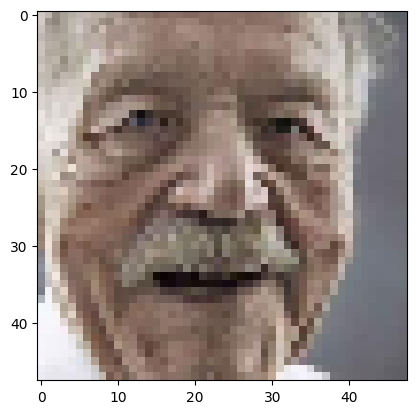

In [ ]:
plt.imshow(images[0])

In [ ]:
print(ages[87])

10


In [ ]:
print(genders[87])

0


In [ ]:
images_f=np.array(images)
ages_f=np.array(ages)
genders_f=np.array(genders)
np.save(file+'images.npy',images_f)
np.save(file+'ages.npy',ages_f)
np.save(file+'genders.npy',genders_f)

## finding the number of elements in the dataset

finding the number of male and female respectively

In [ ]:
values,counts=np.unique(genders_f,return_counts=True)
print(counts)

[12391 11317]


numbers of male images=12391 ,number of females=11317

##plotting the number of males and females sample

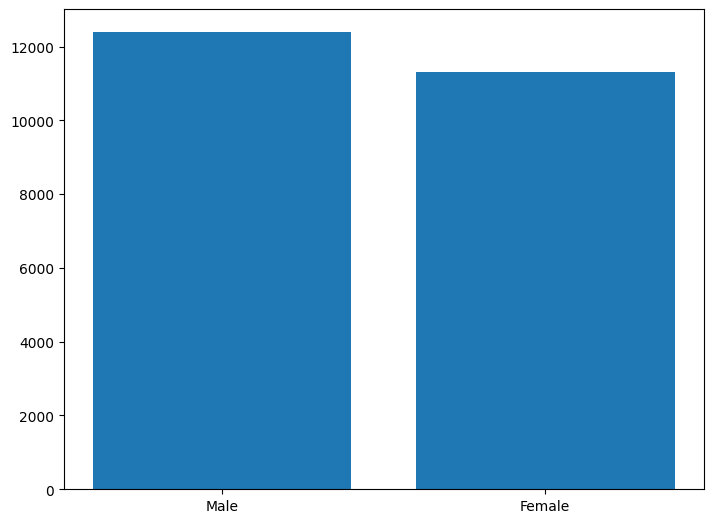

In [ ]:
fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
gender=['Male','Female']
values=[12391,11317]
ax.bar(gender,values)
plt.show()

finding the number of samples in each age

In [ ]:
values, counts=np.unique(ages_f,return_counts=True)
print(counts)

[1123  482  289  273  196  131  139  263  166  156   65  130   81  157
  177  247  158  262   98  284  346  395  426  859  734 2197  615  918
  570  724  350  664  143  409  880  483  293  325  266  526  132  266
  157  100  440  153  170  153  148  381  138  232  241  353  268  236
   97  271   82  293  161  125  103   50  259   77   94  100   56  147
   33   98   63   32  148   58   28   69   23  133   22   40   18   24
  155   35   10   34   33   82    2   13    5    9   17    9   11    2
    1    5    5    1    3    4]


#converting age counts to lists

In [ ]:
val=values.tolist()
cnt=counts.tolist()

plotting the sample ageswise

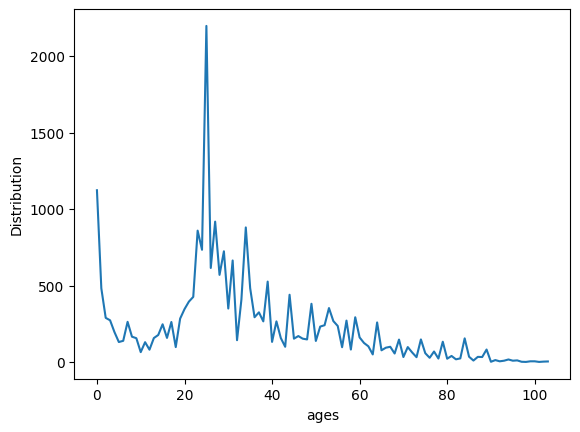

In [ ]:
plt.plot(counts)
plt.xlabel('ages')
plt.ylabel('Distribution')
plt.show()

In [ ]:
len(genders)

23708

In [ ]:
len(ages)

23708

defining labels for output

In [ ]:
labels=[]
i=0
while i<min(len(ages), len(genders)):
    label=[]
    label.append(ages[i])
    label.append(genders[i])
    labels.append(label)
    i=i+1

creating another list of images from existing one
###for better learning 

In [ ]:
images_f_2=images_f/255

In [ ]:
images_f_2.shape

(23708, 48, 48, 3)

In [ ]:
labels_f=np.array(labels)

splitting data into training and testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
labels_f = labels_f[:len(images_f_2)]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(images_f_2, labels_f, test_size=0.25)


In [ ]:
Y_train[0:5]

array([[24,  1],
       [24,  1],
       [15,  0],
       [26,  1],
       [26,  1]])

splitting y_train and y_test further for better understandding

In [ ]:
Y_train_2=[Y_train[:,1],Y_train[:,0]]
Y_test_2=[Y_test[:,1],Y_test[:,0]]

In [ ]:
Y_train_2[0][0:5]

array([1, 1, 0, 1, 1])

In [ ]:
Y_train_2[1][0:5]

array([24, 24, 15, 26, 26])

### defining the model

In [ ]:
def Convolution(input_tensor,filters):
    x=Conv2D(filters=filters,kernel_size=(3,3),padding="same",strides=(1,1),kernel_regularizer=l2(0.001))(input_tensor)
    x=Dropout(0.1)(x)
    x=Activation('relu')(x)
    return x

In [ ]:
# from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# from tensorflow.keras.models import Model

# def create_model(input_shape): 
#     inputs = Input(shape=input_shape)

#     conv_1 = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
#     maxp_1 = MaxPooling2D(pool_size=(2,2))(conv_1)

#     conv_2 = Conv2D(64, (3,3), activation='relu', padding='same')(maxp_1)
#     maxp_2 = MaxPooling2D(pool_size=(2,2))(conv_2)

#     conv_3 = Conv2D(128, (3,3), activation='relu', padding='same')(maxp_2)
#     maxp_3 = MaxPooling2D(pool_size=(2,2))(conv_3)

#     conv_4 = Conv2D(256, (3,3), activation='relu', padding='same')(maxp_3)
#     maxp_4 = MaxPooling2D(pool_size=(2,2))(conv_4)

#     flatten = Flatten()(maxp_4)

#     dense_1 = Dense(64, activation='relu')(flatten)
#     dense_2 = Dense(64, activation='relu')(flatten)

#     drop_1 = Dropout(0.2)(dense_1)
#     drop_2 = Dropout(0.2)(dense_2)

#     output_1 = Dense(1, activation='sigmoid', name='sex_out')(drop_1)
#     output_2 = Dense(1, activation='relu', name='age_out')(drop_2)

#     model = Model(inputs=[inputs], outputs=[output_1, output_2])

#     model.compile(loss=["binary_crossentropy", "mae"], optimizer="Adam", metrics=["accuracy"])

#     return model

# # Example of calling the function
# model = create_model((48, 48, 3))
# model.summary()


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

def model(input_shape):
    inputs=Input((input_shape))
    conv_1=Convolution(inputs,32)
    maxp_1=MaxPooling2D(pool_size=(2,2))(conv_1)
    conv_2=Convolution(maxp_1,64)
    maxp_2=MaxPooling2D(pool_size=(2,2))(conv_2)
    conv_3=Convolution(maxp_2,128)
    maxp_3=MaxPooling2D(pool_size=(2,2))(conv_3)
    conv_4=Convolution(maxp_3,256)
    maxp_4=MaxPooling2D(pool_size=(2,2))(conv_4)
    flatten= Flatten()(maxp_4)
    dense_1=Dense(64,activation='relu')(flatten)
    dense_2=Dense(64,activation='relu')(flatten)
    drop_1=Dropout(0.2)(dense_1)
    drop_2=Dropout(0.2)(dense_2)
    output_1=Dense(1,activation='sigmoid',name='sex_out')(drop_1)
    output_2=Dense(1,activation='relu',name='age_out')(drop_2)
    model=Model(inputs=[inputs],outputs=[output_1,output_2])
    model.compile(loss=["binary_crossentropy","mae"],optimizer="Adam",metrics={"sex_out":["accuracy"],"age_out":["mae"]})
    return model

In [ ]:
Model=model((48,48,3))

In [ ]:
Model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 48, 48,    │          0 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 48, 48,    │          0 │ dropout_6[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 24, 24,    │          0 │ activation_4[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 24,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 24, 24,    │          0 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 24, 24,    │          0 │ dropout_7[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 12, 12,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 12, 12,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 12, 12,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 12, 12,    │          0 │ dropout_8[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 6, 6, 128) │          0 │ activation_6[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 6, 6, 256) │    295,168 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 6, 6, 256) │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 6, 6, 256) │          0 │ dropout_9[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 3, 3, 256) │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 683,586 (2.61 MB)

 Trainable params: 683,586 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
fle_s='Age_Sex_Detection.keras'
checkpoint=ModelCheckpoint(fle_s,monitor='val_loss',verbose=1,save_best_only=True,save_weights_only=False,mode='auto',save_freq='epoch')
Early_stop=tf.keras.callbacks.EarlyStopping(patience=75,monitor='val_loss',restore_best_weights='True')
callback_list=[checkpoint,Early_stop]

In [ ]:
# History = model.fit( X_train,  Y_train_2,  # Two outputs
#     batch_size=64,
#     validation_data=(X_test, Y_test_2),  # Two outputs
#     epochs=2,
#     callbacks=callback_list
# )


In [ ]:
History=Model.fit(
    X_train,Y_train_2,
    batch_size=64,
    validation_data=(X_test,Y_test_2),
    epochs=5,
    callbacks=callback_list
    )

Epoch 1/5


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_24']
Received: inputs=Tensor(shape=(None, 48, 48, 3))
  warnings.warn(msg)


278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - age_out_loss: 17.5452 - age_out_mae: 17.5452 - loss: 18.4736 - sex_out_accuracy: 0.5127 - sex_out_loss: 0.7290
Epoch 1: val_loss improved from inf to 17.15814, saving model to Age_Sex_Detection.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - age_out_loss: 17.5398 - age_out_mae: 17.5398 - loss: 18.4680 - sex_out_accuracy: 0.5127 - sex_out_loss: 0.7289 - val_age_out_loss: 16.3222 - val_age_out_mae: 16.3181 - val_loss: 17.1581 - val_sex_out_accuracy: 0.5197 - val_sex_out_loss: 0.6925
Epoch 2/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - age_out_loss: 14.2770 - age_out_mae: 14.2770 - loss: 15.1228 - sex_out_accuracy: 0.5469 - sex_out_loss: 0.6853
Epoch 2: val_loss improved from 17.15814 to 13.60194, saving model to Age_Sex_Detection.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - age_out_loss: 14.2729 - age_out_mae: 14.2729 - loss: 15.1188 - sex_out_accuracy: 0.5470 - sex_out_loss: 0.6853 - val_age_out_loss: 12.7901 - val_age_out_mae: 12.78

##Model Evaluation

In [ ]:
Model.evaluate(X_test,Y_test_2)

186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - age_out_loss: 12.7228 - age_out_mae: 12.7227 - loss: 13.5413 - sex_out_accuracy: 0.7111 - sex_out_loss: 0.5998


[13.601941108703613,
 0.5955036282539368,
 12.800687789916992,
 12.787638664245605,
 0.718069851398468]

In [ ]:
pred=Model.predict(X_test)

 12/186 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_24']
Received: inputs=Tensor(shape=(32, 48, 48, 3))
  warnings.warn(msg)


186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [ ]:
pred[1]

array([[ 0.44766504],
       [32.0126    ],
       [16.03194   ],
       ...,
       [21.346022  ],
       [18.56124   ],
       [ 4.399535  ]], dtype=float32)

#plotting loss

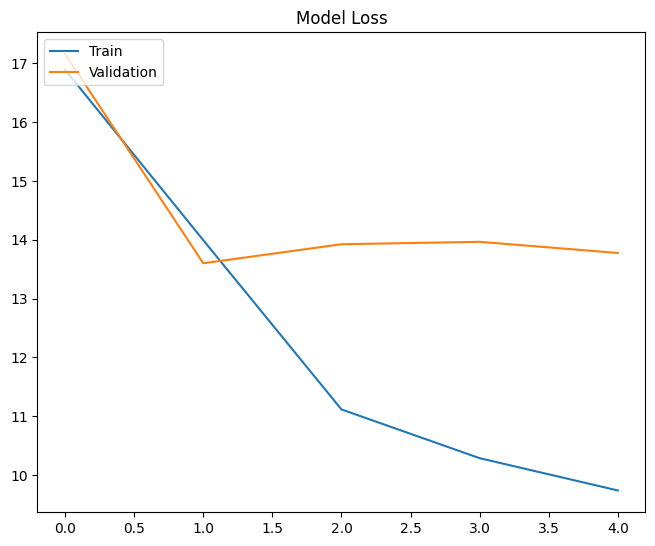

In [ ]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.xlabel=('Epoch')
plt.ylabel=('Loss')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)

#Plotting Sex Accuracy

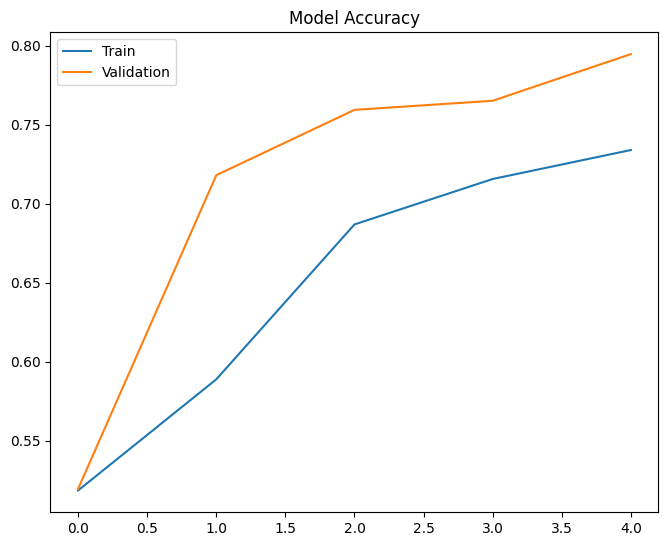

In [ ]:
plt.plot(History.history['sex_out_accuracy'])
plt.plot(History.history['val_sex_out_accuracy'])
plt.title('Model Accuracy')
plt.xlabel=('Epoch')
plt.ylabel=('Accuracy')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)

##Plotting gender acuuracy

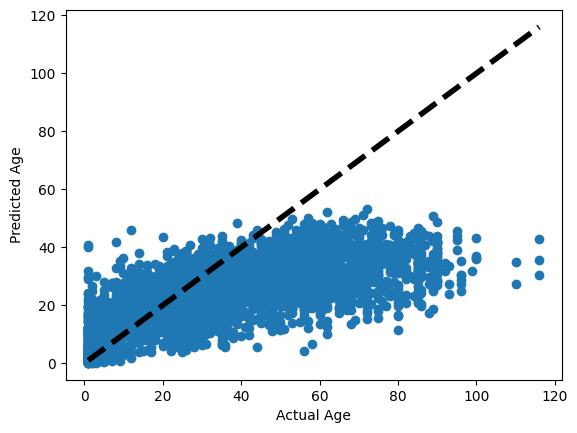

In [ ]:
fig,ax=plt.subplots()
ax.scatter(Y_test_2[1],pred[1])
ax.plot([Y_test_2[1].min(),Y_test_2[1].max()],[Y_test_2[1].min(),Y_test_2[1].max()],'k--',lw=4)
ax.set_xlabel('Actual Age')
ax.set_ylabel('Predicted Age')
plt.show()

##Making Report of the Model (Gender Only)

In [ ]:
i=0
Pred_l=[]
while(i<len(pred[0])):
    Pred_l.append(int(np.round(pred[0][i])))
    i=i+1
    

C:\Users\user\AppData\Local\Temp\ipykernel_22576\2690061568.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Pred_l.append(int(np.round(pred[0][i])))


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
report=classification_report(Y_test_2[0],Pred_l)

In [ ]:
print(report)

              precision    recall  f1-score   support

           0       0.69      0.84      0.75      3080
           1       0.77      0.59      0.67      2847

    accuracy                           0.72      5927
   macro avg       0.73      0.71      0.71      5927
weighted avg       0.73      0.72      0.71      5927



##Making Heatmap of the Model (Gender only)

In [ ]:
results=confusion_matrix(Y_test_2[0],Pred_l)

<Axes: >

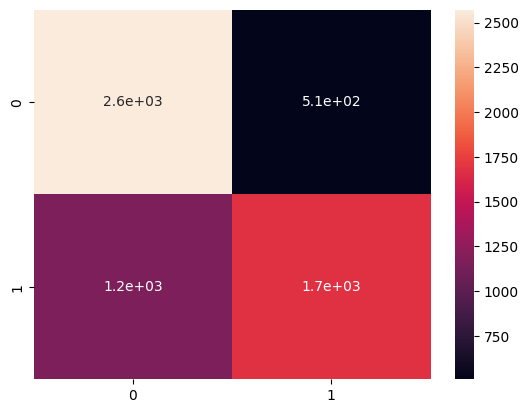

In [ ]:
import seaborn as sns
sns.heatmap(results,annot=True)

##Testing The Images Ourself

In [ ]:
def test_image(ind,images_f,images_f_2,Model):
    plt.imshow(images_f[ind])
    image_test=images_f_2[ind]
    pred_l=Model.predict(np.array([image_test]))
    sex_f=['Male','Female']
    age=int(np.round(pred_l[1][0]))
    sex=int(np.round(pred_l[0][0]))
    print("Predicted Age is "+ str(age))
    print("Predicted Gender is "+ sex_f[sex])

#test1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Age is 39
Predicted Gender is Male


C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_l[1][0]))
C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_l[0][0]))


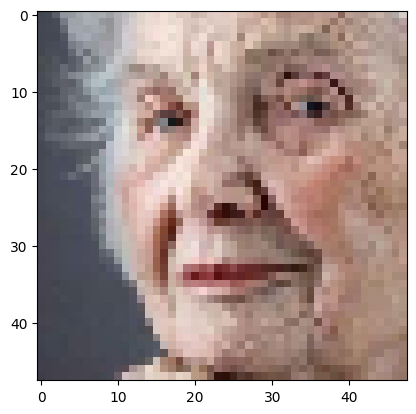

In [ ]:
test_image(4,images_f,images_f_2,Model)

#test2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Age is 23
Predicted Gender is Male


C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_l[1][0]))
C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_l[0][0]))


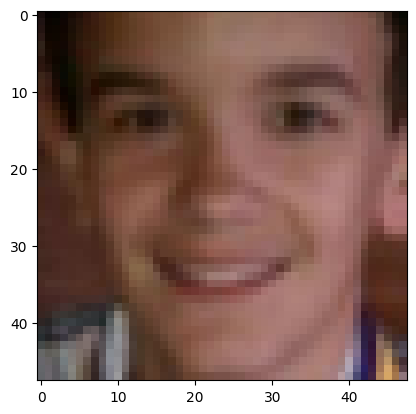

In [ ]:
test_image(23,images_f,images_f_2,Model)

#test 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Age is 19
Predicted Gender is Female


C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_l[1][0]))
C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_l[0][0]))


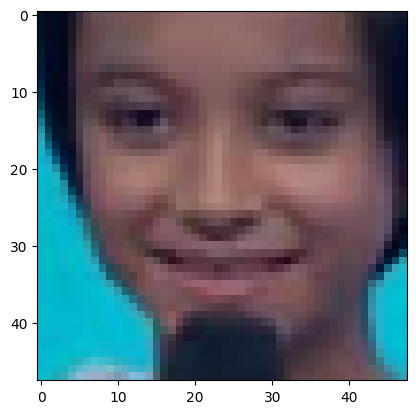

In [ ]:
test_image(168,images_f,images_f_2,Model)

#test 4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Age is 29
Predicted Gender is Male


C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_l[1][0]))
C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_l[0][0]))


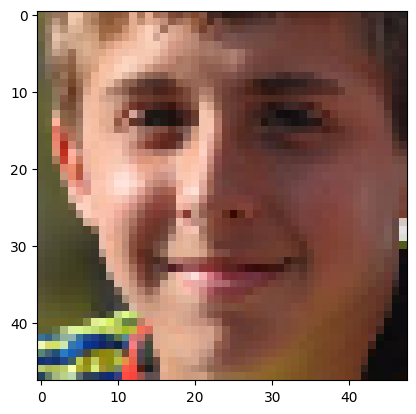

In [ ]:
test_image(888,images_f,images_f_2,Model)

#test 5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Age is 20
Predicted Gender is Female


C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_l[1][0]))
C:\Users\user\AppData\Local\Temp\ipykernel_22576\964136747.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_l[0][0]))


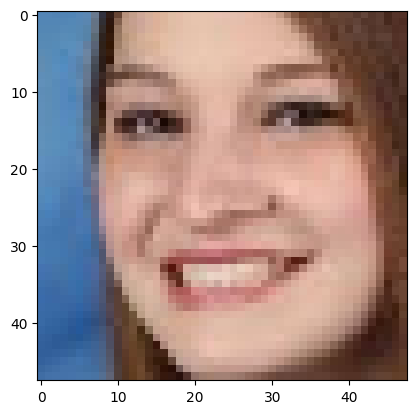

In [ ]:
test_image(1288,images_f,images_f_2,Model)